In [1]:
import time
import torch
import tensorflow as tf
import psutil

class PowerMonitor:
    def __init__(self):
        self.gpu_available = tf.config.list_physical_devices('GPU')
        
        # Hardware power specifications (adjust these values for your system)
        self.cpu_tdp = 65    # Typical TDP for desktop CPUs in watts
        self.gpu_tdp = 250   # Typical TDP for desktop GPUs in watts
        
    def get_stats(self):
        """Get system stats with power estimation"""
        stats = {
            'timestamp': time.time(),
            'cpu_%': psutil.cpu_percent(interval=0.1),
            'ram_mb': psutil.virtual_memory().used / (1024**2),
            'gpu_mem_mb': 0,
            'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85  # Base CPU power
        }
        
        if self.gpu_available:
            try:
                # TensorFlow GPU memory monitoring
                mem_info = tf.config.experimental.get_memory_info('GPU:0')
                stats.update({
                    'gpu_mem_mb': mem_info['current'] / (1024**2),
                    'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85 + 
                              self.gpu_tdp * 0.5 * 0.75  # Add GPU power estimate
                })
            except:
                pass
                
        return stats

# Initialize monitor
monitor = PowerMonitor()

c:\Users\aneek\anaconda3\envs\tf_gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


def build_meso4_model(input_shape=(160, 160, 3)):
    """
    Meso-4 architecture adapted to the standardized benchmark.

    Initialization:
        Random initialization

    Input:
        uint8 OpenCV BGR images

    Labels:
        0 = real
        1 = fake
    """

    inputs = layers.Input(
        shape=input_shape,
        dtype=tf.uint8,
        name="input_images"
    )

    # OpenCV images: BGR -> RGB
    x = layers.Lambda(
        lambda image: tf.reverse(
            tf.cast(image, tf.float32),
            axis=[-1]
        ),
        name="bgr_to_rgb"
    )(inputs)

    # Normalize [0, 255] -> [0, 1]
    x = layers.Rescaling(
        scale=1.0 / 255.0,
        name="meso4_preprocessing"
    )(x)

    # Block 1
    x = layers.Conv2D(
        8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="block1_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block1_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="block1_pool"
    )(x)

    # Block 2
    x = layers.Conv2D(
        8,
        kernel_size=(5, 5),
        padding="same",
        activation="relu",
        name="block2_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block2_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="block2_pool"
    )(x)

    # Block 3
    x = layers.Conv2D(
        16,
        kernel_size=(5, 5),
        padding="same",
        activation="relu",
        name="block3_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block3_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="block3_pool"
    )(x)

    # Block 4
    x = layers.Conv2D(
        16,
        kernel_size=(5, 5),
        padding="same",
        activation="relu",
        name="block4_conv"
    )(x)

    x = layers.BatchNormalization(
        name="block4_batchnorm"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(4, 4),
        padding="same",
        name="block4_pool"
    )(x)

    # Official-style classifier structure
    x = layers.Flatten(
        name="flatten"
    )(x)

    x = layers.Dropout(
        0.5,
        name="dropout_1"
    )(x)

    x = layers.Dense(
        16,
        name="dense_16"
    )(x)

    # Use alpha for compatibility with older Keras versions
    x = layers.LeakyReLU(
        alpha=0.1,
        name="leaky_relu"
    )(x)

    x = layers.Dropout(
        0.5,
        name="dropout_2"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Meso4_Deepfake_Detector"
    )

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model


model = build_meso4_model(
    input_shape=(160, 160, 3)
)

model.summary()

print(
    "\nTrainable parameters:",
    sum(
        tf.keras.backend.count_params(variable)
        for variable in model.trainable_weights
    )
)

Model: "Meso4_Deepfake_Detector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_images (InputLayer)   [(None, 160, 160, 3)]     0         
                                                                 
 bgr_to_rgb (Lambda)         (None, 160, 160, 3)       0         
                                                                 
 meso4_preprocessing (Rescal  (None, 160, 160, 3)      0         
 ing)                                                            
                                                                 
 block1_conv (Conv2D)        (None, 160, 160, 8)       224       
                                                                 
 block1_batchnorm (BatchNorm  (None, 160, 160, 8)      32        
 alization)                                                      
                                                                 
 block1_pool (MaxPooling2D)  (None, 80, 80,

# Wild deepfake

In [13]:
import h5py
import numpy as np

H5_PATH = (
    r"D:\thesis\dataset\WildDeepfake\leakage_free_subset"
    r"\wilddeepfake_sequence_disjoint_face_preprocessed.h5"
)

with h5py.File(H5_PATH, "r") as h5f:
    # Load image arrays
    train_images = h5f["train_images"][:]
    train_labels = h5f["train_labels"][:]

    val_images = h5f["val_images"][:]
    val_labels = h5f["val_labels"][:]

    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

# Verify dataset sizes
print(f"Total train: {len(train_images)} images")
print(f"Total validation: {len(val_images)} images")
print(f"Total test: {len(test_images)} images")

print(f"Train labels: {len(train_labels)}")
print(f"Validation labels: {len(val_labels)}")
print(f"Test labels: {len(test_labels)}")

# Verify shapes and data types
print("\nArray information:")
print(f"Train images: {train_images.shape}, dtype={train_images.dtype}")
print(f"Validation images: {val_images.shape}, dtype={val_images.dtype}")
print(f"Test images: {test_images.shape}, dtype={test_images.dtype}")

print(f"Train labels: {train_labels.shape}, dtype={train_labels.dtype}")
print(f"Validation labels: {val_labels.shape}, dtype={val_labels.dtype}")
print(f"Test labels: {test_labels.shape}, dtype={test_labels.dtype}")

# Verify class distributions
print("\nClass distribution:")
print(
    f"Train: Real={np.sum(train_labels == 0)}, "
    f"Fake={np.sum(train_labels == 1)}"
)
print(
    f"Validation: Real={np.sum(val_labels == 0)}, "
    f"Fake={np.sum(val_labels == 1)}"
)
print(
    f"Test: Real={np.sum(test_labels == 0)}, "
    f"Fake={np.sum(test_labels == 1)}"
)

Total train: 36000 images
Total validation: 6000 images
Total test: 18000 images
Train labels: 36000
Validation labels: 6000
Test labels: 18000

Array information:
Train images: (36000, 160, 160, 3), dtype=uint8
Validation images: (6000, 160, 160, 3), dtype=uint8
Test images: (18000, 160, 160, 3), dtype=uint8
Train labels: (36000,), dtype=uint8
Validation labels: (6000,), dtype=uint8
Test labels: (18000,), dtype=uint8

Class distribution:
Train: Real=9000, Fake=27000
Validation: Real=1500, Fake=4500
Test: Real=4500, Fake=13500


In [4]:

# Train model
history = model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
2250/2250 [==============================] - 26s 9ms/step - loss: 0.7164 - accuracy: 0.6933 - precision: 0.7614 - recall: 0.8607 - roc_auc: 0.5676 - pr_auc: 0.7882 - val_loss: 0.5242 - val_accuracy: 0.7497 - val_precision: 0.7502 - val_recall: 0.9989 - val_roc_auc: 0.6918 - val_pr_auc: 0.8673
Epoch 2/10
2250/2250 [==============================] - 19s 8ms/step - loss: 0.5890 - accuracy: 0.7234 - precision: 0.7601 - recall: 0.9223 - roc_auc: 0.5901 - pr_auc: 0.8082 - val_loss: 0.5180 - val_accuracy: 0.7500 - val_precision: 0.7500 - val_recall: 1.0000 - val_roc_auc: 0.7164 - val_pr_auc: 0.8882
Epoch 3/10
2250/2250 [==============================] - 19s 8ms/step - loss: 0.5582 - accuracy: 0.7369 - precision: 0.7620 - recall: 0.9440 - roc_auc: 0.6311 - pr_auc: 0.8344 - val_loss: 0.5019 - val_accuracy: 0.7502 - val_precision: 0.7501 - val_recall: 1.0000 - val_roc_auc: 0.7400 - val_pr_auc: 0.9024
Epoch 4/10
2250/2250 [==============================] - 19s 8ms/step - loss: 0.5352 -

In [5]:
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

1125/1125 [==============================] - 4s 4ms/step - loss: 0.5029 - accuracy: 0.7680 - precision: 0.7696 - recall: 0.9859 - roc_auc: 0.7277 - pr_auc: 0.8770

Test results:
loss: 0.5029
accuracy: 0.7680
precision: 0.7696
recall: 0.9859
roc_auc: 0.7277
pr_auc: 0.8770


save the model

In [6]:
import tensorflow as tf

# After training the model
model.save('Mesonet_160_wild.h5')  # Saves the entire model to a file

In [7]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_wilddeepfake_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
D:\thesis\results\Mesonet_wilddeepfake_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


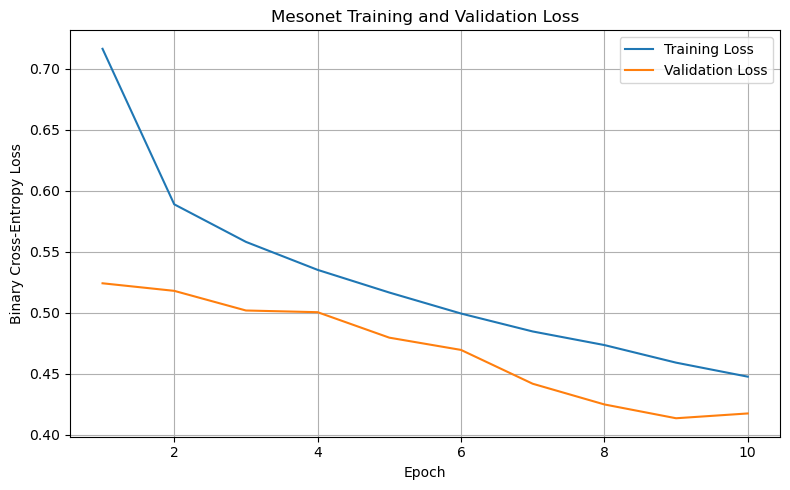

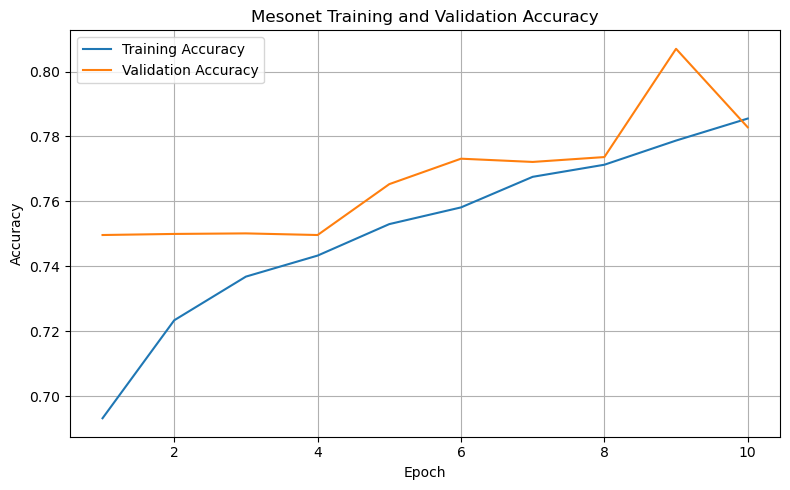

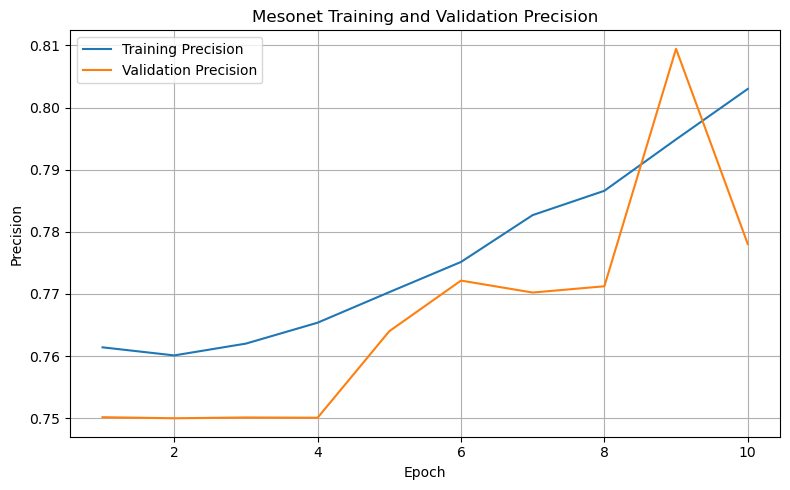

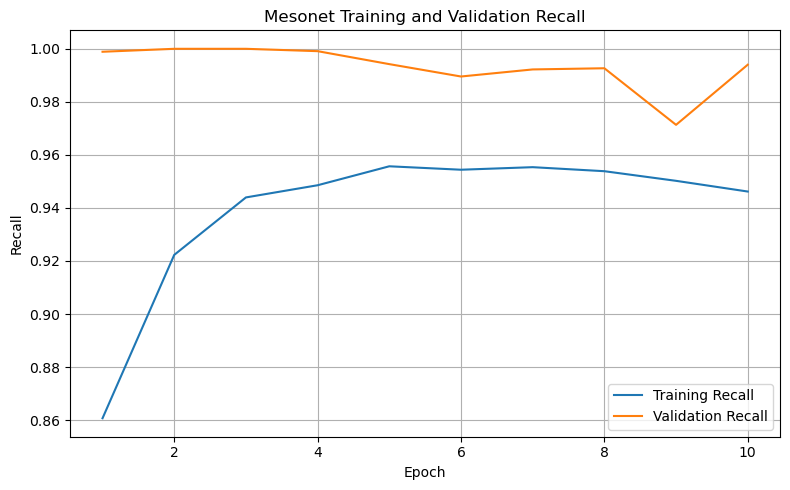

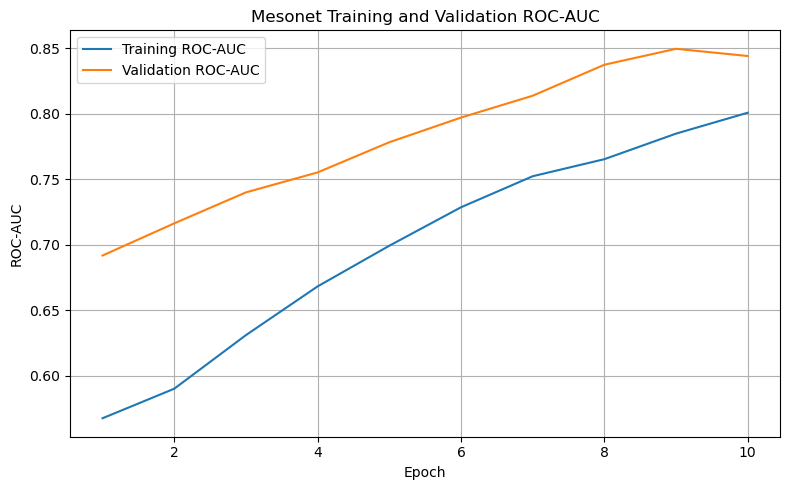

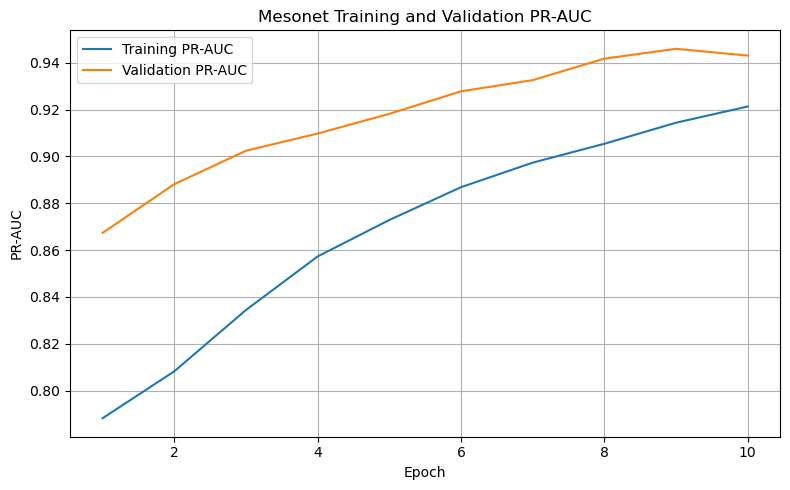

In [15]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Mesonet_wilddeepfake_10epochs.h5")

H5_PATH = (
    r"D:\thesis\dataset\WildDeepfake\leakage_free_subset"
    r"\wilddeepfake_sequence_disjoint_face_preprocessed.h5"
)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

# Load only the test split
with h5py.File(H5_PATH, "r") as h5f:
    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

print("Model loaded")
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Model loaded
Test images: (18000, 160, 160, 3)
Test labels: (18000,)


In [8]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [10]:
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

1125/1125 [==============================] - 4s 4ms/step - loss: 0.5029 - accuracy: 0.7680 - precision: 0.7696 - recall: 0.9859 - roc_auc: 0.7277 - pr_auc: 0.8770

Test results:
loss: 0.5029
accuracy: 0.7680
precision: 0.7696
recall: 0.9859
roc_auc: 0.7277
pr_auc: 0.8770


In [11]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 11.1%
RAM Used: -4305.3 MB
Time Usage: 85.6 s
GPU Memory Used: 0.2 MB
Power Consumption: 93W


In [12]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_images),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_images[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_images,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_images)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_17588\2159758100.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 3.20 seconds, 0.1778 ms/image

Starting resource run 2/5
Run 2: 2.81 seconds, 0.1561 ms/image

Starting resource run 3/5
Run 3: 2.87 seconds, 0.1597 ms/image

Starting resource run 4/5
Run 4: 2.84 seconds, 0.1580 ms/image

Starting resource run 5/5
Run 5: 2.82 seconds, 0.1566 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,3.201011,0.177834,5623.222886,3.391741,6.753125,8212.484375,9442.038365,9576.000000,1229.553990,1363.515625,...,6954.613281,6954.613281,0.0,0.0,59.142857,100,38.541857,52.856,0.031426,1
1,2.809928,0.156107,6405.858086,3.846034,7.168750,8257.402344,9475.422776,9614.730469,1218.020433,1357.328125,...,6954.613281,6954.613281,0.0,0.0,63.500000,92,35.238538,55.666,0.026931,2
2,2.874211,0.159678,6262.589327,3.843870,7.168750,8257.718750,9474.104417,9614.507812,1216.385667,1356.789062,...,6954.613281,6954.613281,0.0,0.0,64.500000,100,36.049115,57.027,0.027909,3
3,2.844241,0.158013,6328.576752,3.482933,5.250000,8259.437500,9475.084736,9616.492188,1215.647236,1357.054688,...,6954.613281,6954.613281,0.0,0.0,65.038462,100,37.188423,54.450,0.028163,4
4,2.819505,0.156639,6384.100016,3.679625,5.375000,8260.238281,9475.706719,9617.347656,1215.468437,1357.109375,...,6954.613281,6954.613281,0.0,0.0,64.640000,100,36.560320,52.027,0.027629,5


In [13]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,2.909779,0.164694,2.705285,3.114274
1,latency_ms_per_image,0.161654,0.009150,0.150294,0.173015
2,throughput_images_per_s,6200.869413,327.638456,5794.052538,6607.686289
3,average_cpu_percent,3.648841,0.207060,3.391742,3.905939
4,peak_cpu_percent,6.343125,0.957027,5.154819,7.531431
5,average_ram_mb,9468.471403,14.788880,9450.108583,9486.834223
6,peak_ram_mb,9607.815625,17.825381,9585.682492,9629.948758
7,average_incremental_ram_mb,1219.015153,5.976889,1211.593865,1226.436440
8,peak_incremental_ram_mb,1358.359375,2.888814,1354.772439,1361.946311
9,average_gpu_memory_mb,6954.613281,0.000000,6954.613281,6954.613281



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.162 ± 0.009 (95% CI: 0.150–0.173)
peak_ram_mb: 9607.816 ± 17.825 (95% CI: 9585.682–9629.949)
peak_gpu_memory_mb: 6954.613 ± 0.000 (95% CI: 6954.613–6954.613)
average_gpu_utilization_percent: 63.364 ± 2.427 (95% CI: 60.351–66.378)
average_gpu_power_w: 36.716 ± 1.246 (95% CI: 35.169–38.263)


In [14]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_images,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_images,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

1125/1125 [==============================] - 2s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     18000
Decision threshold:         0.5000
Test loss:                  0.502902

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.768000 (76.80%)
Precision:                  0.769573 (76.96%)
Recall/Sensitivity:         0.985852 (98.59%)
F1-score:                   0.864389 (86.44%)
ROC-AUC:                    0.727779
PR-AUC:                     0.876994
Average Precision:          0.877004
EER:                        0.341259 (34.13%)
EER threshold:              0.703021

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.550148
Specificity:                0.114444
Matthews correlation:       0.223722
False-positive rate @ 0.5:  0.885556
False-negative rate @ 0.5:  0.014148

Confusion matrix
------------------

genralization

In [17]:
#celeb on wilddeepfake
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on Celeb-DF(V2) (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 2s 4ms/step - loss: 0.6490 - accuracy: 0.7198 - precision: 0.9154 - recall: 0.7605 - roc_auc: 0.5713 - pr_auc: 0.9192

Test results of wild deepfake dataset on Celeb-DF(V2) (Mesonet):
loss: 0.6490
accuracy: 0.7198
precision: 0.9154
recall: 0.7605
roc_auc: 0.5713
pr_auc: 0.9192


In [19]:
#dfc on wilddeepfake

test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on DFC (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

188/188 [==============================] - 1s 6ms/step - loss: 0.8049 - accuracy: 0.5517 - precision: 0.5315 - recall: 0.8713 - roc_auc: 0.5899 - pr_auc: 0.5506

Test results of wild deepfake dataset on DFC (Mesonet):
loss: 0.8049
accuracy: 0.5517
precision: 0.5315
recall: 0.8713
roc_auc: 0.5899
pr_auc: 0.5506


In [21]:
#ff++ on wilddeepfake

test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on FF++ (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

155/155 [==============================] - 1s 4ms/step - loss: 0.8970 - accuracy: 0.5297 - precision: 0.3978 - recall: 0.2512 - roc_auc: 0.4741 - pr_auc: 0.4063  

Test results of wild deepfake dataset on FF++ (Mesonet):
loss: 0.8970
accuracy: 0.5297
precision: 0.3978
recall: 0.2512
roc_auc: 0.4741
pr_auc: 0.4063


# Celeb

In [15]:
import os
import cv2
import numpy as np

SAVE_ROOT = r'D:\thesis\celeb_processed'

def load_split(split_name, class_name):
    """Reload saved frames, grouped by video."""
    base = os.path.join(SAVE_ROOT, split_name, class_name)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        vid_dir = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(vid_dir, f))
                  for f in sorted(os.listdir(vid_dir))]
        if frames:
            nested.append(frames)
            ids.append(vid_id)
    return nested, ids

# Reload ALL six splits
print("Loading frames...")
real_train_final,  real_train_ids  = load_split('train', 'real')
synth_train_final, synth_train_ids = load_split('train', 'fake')
real_val_final,    real_val_ids    = load_split('val',   'real')
synth_val_final,   synth_val_ids   = load_split('val',   'fake')
real_test_final,   real_test_ids   = load_split('test',  'real')
synth_test_final,  synth_test_ids  = load_split('test',  'fake')

print("✅ All frames reloaded")
print("Train -> real videos:", len(real_train_final), " fake videos:", len(synth_train_final))
print("Val   -> real videos:", len(real_val_final),   " fake videos:", len(synth_val_final))
print("Test  -> real videos:", len(real_test_final),  " fake videos:", len(synth_test_final))
print("Example frame shape:", np.shape(real_train_final[0][0]))  # expect (160,160,3)
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Flatten video-grouped frames into one image array and create labels.

    real_videos: list of videos, where each video is a list of frames
    fake_videos: list of videos, where each video is a list of frames

    Returns
    -------
    images : NumPy array with shape (N, 160, 160, 3)
    labels : NumPy array with shape (N,)
             0 = real, 1 = fake
    """

    # Flatten frames from all real videos
    real_frames = [
        frame
        for video_frames in real_videos
        for frame in video_frames
        if frame is not None
    ]

    # Flatten frames from all fake videos
    fake_frames = [
        frame
        for video_frames in fake_videos
        for frame in video_frames
        if frame is not None
    ]

    if len(real_frames) == 0:
        raise ValueError("No real frames were found.")

    if len(fake_frames) == 0:
        raise ValueError("No fake frames were found.")

    # Convert to NumPy arrays
    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    # Combine images
    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    # Create labels
    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training set
train_celeb, train_labels = combine_split(
    real_train_final,
    synth_train_final
)

# Validation set
val_celeb, val_labels = combine_split(
    real_val_final,
    synth_val_final
)

# Testing set
test_celeb, test_labels = combine_split(
    real_test_final,
    synth_test_final
)
print("\nTRAIN")
print("Images:", train_celeb.shape)
print("Labels:", train_labels.shape)
print("Real:", np.sum(train_labels == 0))
print("Fake:", np.sum(train_labels == 1))

print("\nVALIDATION")
print("Images:", val_celeb.shape)
print("Labels:", val_labels.shape)
print("Real:", np.sum(val_labels == 0))
print("Fake:", np.sum(val_labels == 1))

print("\nTEST")
print("Images:", test_celeb.shape)
print("Labels:", test_labels.shape)
print("Real:", np.sum(test_labels == 0))
print("Fake:", np.sum(test_labels == 1))

print("\nData types")
print("Train images:", train_celeb.dtype)
print("Train labels:", train_labels.dtype)

Loading frames...
✅ All frames reloaded
Train -> real videos: 354  fake videos: 3383
Val   -> real videos: 59  fake videos: 563
Test  -> real videos: 177  fake videos: 1693
Example frame shape: (160, 160, 3)

TRAIN
Images: (11899, 160, 160, 3)
Labels: (11899,)
Real: 1142
Fake: 10757

VALIDATION
Images: (1969, 160, 160, 3)
Labels: (1969,)
Real: 182
Fake: 1787

TEST
Images: (5961, 160, 160, 3)
Labels: (5961,)
Real: 571
Fake: 5390

Data types
Train images: uint8
Train labels: uint8


In [4]:

# Train model
history = model.fit(
    train_celeb, train_labels,
    validation_data=(val_celeb, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
744/744 [==============================] - 10s 10ms/step - loss: 0.6137 - accuracy: 0.8307 - precision: 0.9067 - recall: 0.9059 - roc_auc: 0.5205 - pr_auc: 0.9079 - val_loss: 0.3353 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.5299 - val_pr_auc: 0.9111
Epoch 2/10
744/744 [==============================] - 7s 9ms/step - loss: 0.4387 - accuracy: 0.8699 - precision: 0.9054 - recall: 0.9559 - roc_auc: 0.5232 - pr_auc: 0.9104 - val_loss: 0.3170 - val_accuracy: 0.9066 - val_precision: 0.9075 - val_recall: 0.9989 - val_roc_auc: 0.5823 - val_pr_auc: 0.9206
Epoch 3/10
744/744 [==============================] - 7s 9ms/step - loss: 0.4044 - accuracy: 0.8798 - precision: 0.9035 - recall: 0.9707 - roc_auc: 0.5377 - pr_auc: 0.9137 - val_loss: 0.3228 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.5946 - val_pr_auc: 0.9229
Epoch 4/10
744/744 [==============================] - 7s 9ms/step - loss: 0.3837 - accuracy:

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [6]:
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

373/373 [==============================] - 1s 4ms/step - loss: 0.3003 - accuracy: 0.9042 - precision: 0.9042 - recall: 1.0000 - roc_auc: 0.6958 - pr_auc: 0.9484

Test results:
loss: 0.3003
accuracy: 0.9042
precision: 0.9042
recall: 1.0000
roc_auc: 0.6958
pr_auc: 0.9484


In [11]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_celeb,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

373/373 [==============================] - 1s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     5961
Decision threshold:         0.5000
Test loss:                  0.300342

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.904211 (90.42%)
Precision:                  0.904211 (90.42%)
Recall/Sensitivity:         1.000000 (100.00%)
F1-score:                   0.949696 (94.97%)
ROC-AUC:                    0.696035
PR-AUC:                     0.948554
Average Precision:          0.948590
EER:                        0.353784 (35.38%)
EER threshold:              0.866379

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.500000
Specificity:                0.000000
Matthews correlation:       0.000000
False-positive rate @ 0.5:  1.000000
False-negative rate @ 0.5:  0.000000

Confusion matrix
--------------------

In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 8.3%
RAM Used: 476.5 MB
Time Usage: 3.8 s
GPU Memory Used: 1452.6 MB
Power Consumption: 93W


save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_celeb_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Mesonet_160_celeb.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Mesonet_celeb_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


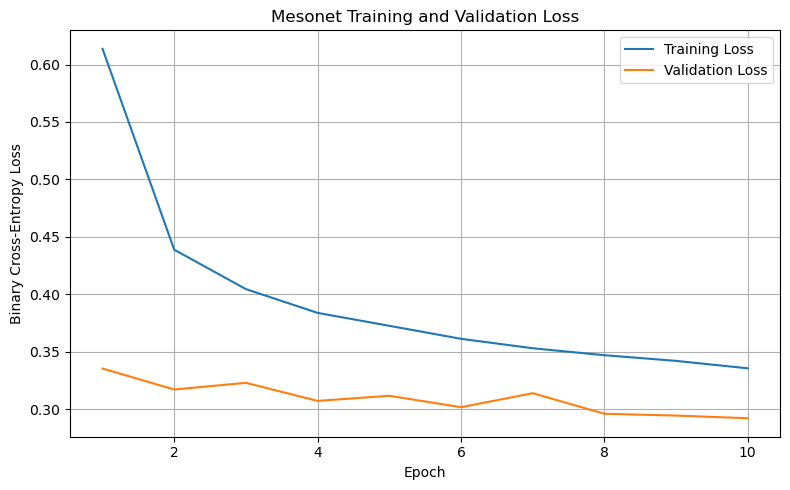

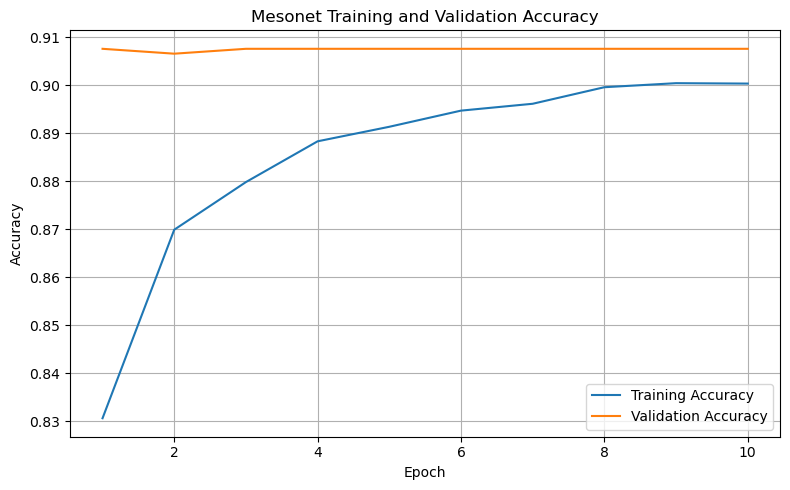

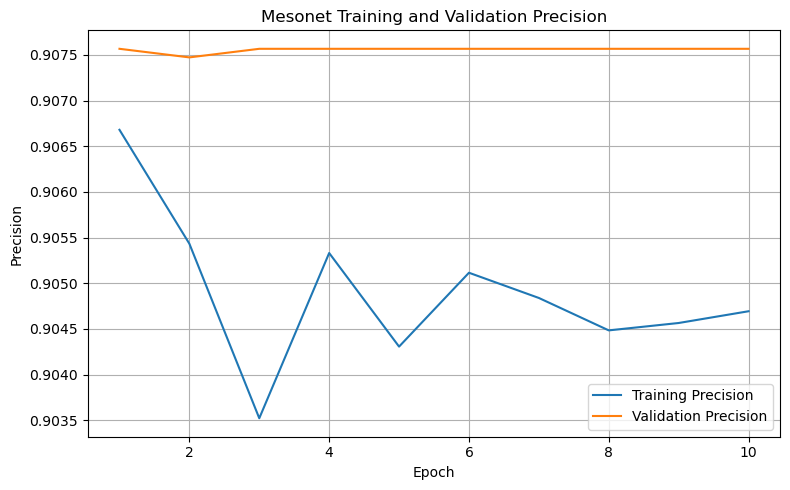

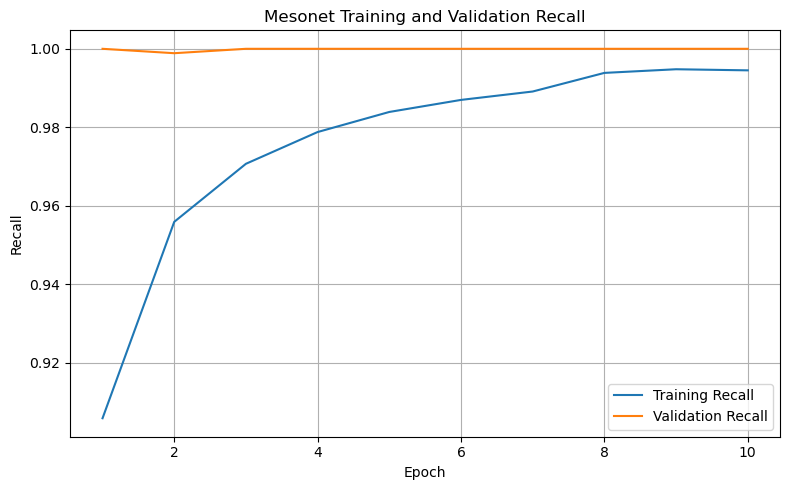

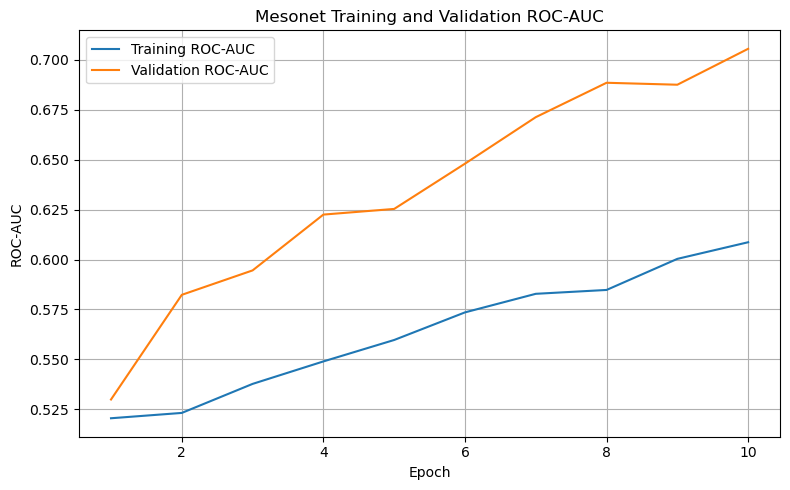

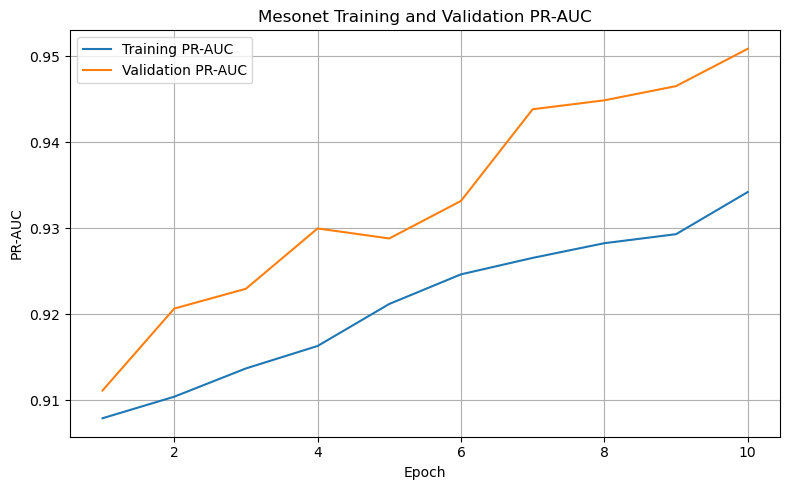

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Mesonet_celeb_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Mesonet_160_celeb.h5")


In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_celeb),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_celeb[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_celeb,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_celeb)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_30332\3984712684.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 1.29 seconds, 0.2157 ms/image

Starting resource run 2/5
Run 2: 1.09 seconds, 0.1822 ms/image

Starting resource run 3/5
Run 3: 1.10 seconds, 0.1842 ms/image

Starting resource run 4/5
Run 4: 1.06 seconds, 0.1784 ms/image

Starting resource run 5/5
Run 5: 0.97 seconds, 0.1625 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,1.285681,0.215682,4636.454448,3.171875,5.375000,6727.640625,7115.029297,7203.179688,387.388672,475.539062,...,6957.488281,6957.488281,0.0,0.0,61.666667,100,14.337167,32.132,0.004599,1
1,1.085933,0.182173,5489.287418,3.260227,5.375000,6740.773438,7105.402699,7217.195312,364.629261,476.421875,...,6957.488281,6957.488281,0.0,0.0,62.727273,94,22.042818,53.506,0.006627,2
2,1.097981,0.184194,5429.054705,3.261458,5.825000,6742.984375,7118.343424,7218.894531,375.359049,475.910156,...,6957.488281,6957.488281,0.0,0.0,56.500000,95,34.207500,52.127,0.009919,3
3,1.063245,0.178367,5606.421850,2.859943,4.928125,6744.546875,7122.839489,7219.566406,378.292614,475.019531,...,6957.488281,6957.488281,0.0,0.0,56.272727,81,22.078818,51.036,0.006030,4
4,0.968922,0.162543,6152.199280,3.116477,4.725000,6745.226562,7123.924006,7220.585938,378.697443,475.359375,...,6957.488281,6957.488281,0.0,0.0,59.090909,81,18.245636,34.534,0.004569,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,1.100352,0.115338,0.957142,1.243563
1,latency_ms_per_image,0.184592,0.019349,0.160567,0.208617
2,throughput_images_per_s,5462.683540,543.273834,4788.119979,6137.247101
3,average_cpu_percent,3.133996,0.165097,2.929002,3.338991
4,peak_cpu_percent,5.245625,0.430409,4.711202,5.780048
5,average_ram_mb,7117.107783,7.452672,7107.854069,7126.361497
6,peak_ram_mb,7215.884375,7.208515,7206.933822,7224.834928
7,average_incremental_ram_mb,376.873408,8.187253,366.707591,387.039225
8,peak_incremental_ram_mb,475.650000,0.537990,474.981997,476.318003
9,average_gpu_memory_mb,6957.488281,0.000000,6957.488281,6957.488281



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.185 ± 0.019 (95% CI: 0.161–0.209)
peak_ram_mb: 7215.884 ± 7.209 (95% CI: 7206.934–7224.835)
peak_gpu_memory_mb: 6957.488 ± 0.000 (95% CI: 6957.488–6957.488)
average_gpu_utilization_percent: 59.252 ± 2.932 (95% CI: 55.611–62.892)
average_gpu_power_w: 22.182 ± 7.444 (95% CI: 12.939–31.426)


#genralization

In [14]:
#wild deepfake on celeb
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on wild deepfake dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 5s 4ms/step - loss: 0.5988 - accuracy: 0.7462 - precision: 0.7552 - recall: 0.9787 - roc_auc: 0.5066 - pr_auc: 0.7517

Test results of Celeb-DF(V2) on wild deepfake dataset (Mesonet):
loss: 0.5988
accuracy: 0.7462
precision: 0.7552
recall: 0.9787
roc_auc: 0.5066
pr_auc: 0.7517


In [16]:
#DFC on celeb
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on DFC dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



188/188 [==============================] - 1s 6ms/step - loss: 1.5753 - accuracy: 0.4967 - precision: 0.4983 - recall: 0.9893 - roc_auc: 0.3682 - pr_auc: 0.4033

Test results of Celeb-DF(V2) on DFC dataset (Mesonet):
loss: 1.5753
accuracy: 0.4967
precision: 0.4983
recall: 0.9893
roc_auc: 0.3682
pr_auc: 0.4033


In [18]:
#FF++ on celeb
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of Celeb-DF(V2) on FF++ dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 1s 6ms/step - loss: 1.1652 - accuracy: 0.4198 - precision: 0.4174 - recall: 0.9932 - roc_auc: 0.6839 - pr_auc: 0.5633

Test results of Celeb-DF(V2) on FF++ dataset (Mesonet):
loss: 1.1652
accuracy: 0.4198
precision: 0.4174
recall: 0.9932
roc_auc: 0.6839
pr_auc: 0.5633


# DFC

In [17]:
import h5py
import numpy as np
# Open the HDF5 file in read mode
with h5py.File('D://thesis//dataset//deepfake dataset//resized_images.h5', 'r') as h5f:
    # Access each dataset
    celeb = np.array(h5f['celeb'])
    ffhq = np.array(h5f['ffhq'])
    gdwct = np.array(h5f['gdwct'])
    attgan = np.array(h5f['attgan'])
    stargan = np.array(h5f['stargan'])
    stylegan2 = np.array(h5f['stylegan2'])
    stylegan = np.array(h5f['stylegan'])

# Now, 'celeb', 'ffhq', etc., are NumPy arrays containing your datasets
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"ffhq shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"ffhq shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"ffhq shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"ffhq shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"ffhq shape: {stylegan.shape}, dtype: {stylegan.dtype}")
# Repeat for other datasets as needed
import cv2
# Function to resize images from (224, 224) to (160, 160)
def resize_images(image_array, target_size=(160, 160)):
    resized_images = np.array([cv2.resize(img, target_size) for img in image_array])
    return resized_images

celeb = resize_images(celeb, target_size=(160, 160))
ffhq = resize_images(ffhq, target_size=(160, 160))
gdwct = resize_images(gdwct, target_size=(160, 160))
attgan = resize_images(attgan, target_size=(160, 160))
stargan = resize_images(stargan, target_size=(160, 160))
stylegan = resize_images(stylegan, target_size=(160, 160))
stylegan2 = resize_images(stylegan2, target_size=(160, 160))
import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(celeb)), 2500)  # Get 2500 random indices
celeb = celeb[random_indices]  # Select the random subse

import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(ffhq)), 2500)  # Get 2500 random indices
ffhq = ffhq[random_indices]  # Select the random subse
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"gdwct shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"attagan shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"stargan shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"stylegan2 shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"stylegan shape: {stylegan.shape}, dtype: {stylegan.dtype}")
import random
import numpy as np

def split_data(data, train_ratio=0.7):
    """
    Splits data into training and testing sets based on the specified ratio.

    Parameters:
        data (list or np.array): The dataset to split.
        train_ratio (float): The ratio of the data to include in the training set.

    Returns:
        tuple: Two datasets - train and test.
    """
    # Shuffle the data
    random.shuffle(data)

    # Calculate the split index
    split_index = int(len(data) * train_ratio)

    # Split the data
    train_data = data[:split_index]
    test_data = data[split_index:]

    return train_data, test_data

# Split `celeb` into 70% train and 30% test
celeb_train_hog, celeb_test_hog = split_data(celeb, train_ratio=0.7)

# Split `ffhq` into 70% train and 30% test
ffhq_train_hog, ffhq_test_hog = split_data(ffhq, train_ratio=0.7)

# Split `attgan` into 70% train and 30% test
attgan_train_hog, attgan_test_hog = split_data(attgan, train_ratio=0.7)

# Split `stargan` into 70% train and 30% test
stargan_train_hog, stargan_test_hog = split_data(stargan, train_ratio=0.7)

# Split `gdwct` into 70% train and 30% test
gdwct_train_hog, gdwct_test_hog = split_data(gdwct, train_ratio=0.7)

# Split `stylegan2` into 70% train and 30% test_hog
stylegan2_train_hog, stylegan2_test_hog = split_data(stylegan2, train_ratio=0.7)

# Split `stylegan` into 70% train and 30% test_hog
stylegan_train_hog, stylegan_test_hog = split_data(stylegan, train_ratio=0.7)

# Convert to NumPy arrays if needed
celeb_train_hog, celeb_test_hog = np.array(celeb_train_hog), np.array(celeb_test_hog)
ffhq_train_hog, ffhq_test_hog = np.array(ffhq_train_hog), np.array(ffhq_test_hog)
attgan_train_hog, attgan_test_hog = np.array(attgan_train_hog), np.array(attgan_test_hog)
stargan_train_hog, stargan_test_hog = np.array(stargan_train_hog), np.array(stargan_test_hog)
gdwct_train_hog, gdwct_test_hog = np.array(gdwct_train_hog), np.array(gdwct_test_hog)
stylegan2_train_hog, stylegan2_test_hog = np.array(stylegan2_train_hog), np.array(stylegan2_test_hog)
stylegan_train_hog, stylegan_test_hog = np.array(stylegan_train_hog), np.array(stylegan_test_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_test: {len(celeb_test_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_test: {len(ffhq_test_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_test: {len(attgan_test_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_test: {len(stargan_test_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_test: {len(gdwct_test_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_test: {len(stylegan2_test_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_test: {len(stylegan_test_hog)} images")

########################################################################################################################################
#######################################divide into 60,10 train and val
#########################################################################################################################################
def extract_validation(train_data):
    """
    Extract every 10th sample from the training data and store it in a validation set.

    Parameters:
        train_data (list or np.array): The training dataset.

    Returns:
        tuple: Updated training dataset and validation dataset.
    """
    # Select every 10th sample for the validation set
    validation_data = train_data[::10]

    # Remove the selected samples from the training dataset
    updated_train_data = [train_data[i] for i in range(len(train_data)) if i % 10 != 0]

    return np.array(updated_train_data), np.array(validation_data)


# Perform the operation for each dataset
celeb_train_hog, celeb_val_hog = extract_validation(celeb_train_hog)
ffhq_train_hog, ffhq_val_hog = extract_validation(ffhq_train_hog)
attgan_train_hog, attgan_val_hog = extract_validation(attgan_train_hog)
stargan_train_hog, stargan_val_hog = extract_validation(stargan_train_hog)
gdwct_train_hog, gdwct_val_hog = extract_validation(gdwct_train_hog)
stylegan2_train_hog, stylegan2_val_hog = extract_validation(stylegan2_train_hog)
stylegan_train_hog, stylegan_val_hog = extract_validation(stylegan_train_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_val: {len(celeb_val_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_val: {len(ffhq_val_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_val: {len(attgan_val_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_val: {len(stargan_val_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_val: {len(gdwct_val_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_val: {len(stylegan2_val_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_val: {len(stylegan_val_hog)} images")
############################################################################################################################################################
#################################################concatenate the labels 0,1 real and fake
#############################################################################################################################################################


celeb_train_labels = np.zeros(len(celeb_train_hog), dtype=int)
ffhq_train_labels = np.zeros(len(ffhq_train_hog), dtype=int)
atta_train_labels = np.ones(len(attgan_train_hog), dtype=int)
star_train_labels = np.ones(len(stargan_train_hog), dtype=int)
gdwct_train_labels = np.ones(len(gdwct_train_hog), dtype=int)
stylegan2_train_labels = np.ones(len(stylegan2_train_hog), dtype=int)
stylegan_train_labels = np.ones(len(stylegan_train_hog), dtype=int)

# Concatenate all training datasets into a single `train` variable
train_hog = np.concatenate([celeb_train_hog, ffhq_train_hog, attgan_train_hog, stargan_train_hog, gdwct_train_hog, stylegan2_train_hog, stylegan_train_hog], axis=0)
train_labels=np.concatenate([celeb_train_labels, ffhq_train_labels, atta_train_labels, star_train_labels, gdwct_train_labels, stylegan2_train_labels,
                              stylegan_train_labels], axis=0)




celeb_test_labels = np.zeros(len(celeb_test_hog), dtype=int)
ffhq_test_labels = np.zeros(len(ffhq_test_hog), dtype=int)
atta_test_labels = np.ones(len(attgan_test_hog), dtype=int)
star_test_labels = np.ones(len(stargan_test_hog), dtype=int)
gdwct_test_labels = np.ones(len(gdwct_test_hog), dtype=int)
stylegan2_test_labels = np.ones(len(stylegan2_test_hog), dtype=int)
stylegan_test_labels = np.ones(len(stylegan_test_hog), dtype=int)

# Concatenate all testing datasets into a single `test` variable
test_hog = np.concatenate([celeb_test_hog, ffhq_test_hog, attgan_test_hog, stargan_test_hog, gdwct_test_hog, stylegan2_test_hog, stylegan_test_hog], axis=0)
test_labels = np.concatenate([celeb_test_labels, ffhq_test_labels, atta_test_labels, star_test_labels, gdwct_test_labels, stylegan2_test_labels,
                        stylegan_test_labels], axis=0)




celeb_val_labels = np.zeros(len(celeb_val_hog), dtype=int)
ffhq_val_labels = np.zeros(len(ffhq_val_hog), dtype=int)
atta_val_labels = np.ones(len(attgan_val_hog), dtype=int)
star_val_labels = np.ones(len(stargan_val_hog), dtype=int)
gdwct_val_labels = np.ones(len(gdwct_val_hog), dtype=int)
stylegan2_val_labels = np.ones(len(stylegan2_val_hog), dtype=int)
stylegan_val_labels = np.ones(len(stylegan_val_hog), dtype=int)

# Concatenate all validation datasets into a single `val` variable
val_hog = np.concatenate([celeb_val_hog, ffhq_val_hog, attgan_val_hog, stargan_val_hog, gdwct_val_hog, stylegan2_val_hog, stylegan_val_hog], axis=0)
val_labels = np.concatenate([celeb_val_labels, ffhq_val_labels, atta_val_labels, star_val_labels, gdwct_val_labels, stylegan2_val_labels,
                       stylegan_val_labels], axis=0)

# Print the results for verification
print(f"Total train: {len(train_hog)} images")
print(f"Total test: {len(test_hog)} images")
print(f"Total val: {len(val_hog)} images")


# Print results for verification
print(f"Train Labels: {len(train_labels)} ")
print(f"Test Labels: {len(test_labels)} ")
print(f"Val Labels: {len(val_labels)} ")



celeb shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
celeb shape: (2500, 160, 160, 3), dtype: uint8
ffhq shape: (2500, 160, 160, 3), dtype: uint8
gdwct shape: (1000, 160, 160, 3), dtype: uint8
attagan shape: (1000, 160, 160, 3), dtype: uint8
stargan shape: (1000, 160, 160, 3), dtype: uint8
stylegan2 shape: (1000, 160, 160, 3), dtype: uint8
stylegan shape: (1000, 160, 160, 3), dtype: uint8
celeb_train: 1750 images, celeb_test: 750 images
ffhq_train: 1750 images, ffhq_test: 750 images
attgan_train: 700 images, attgan_test: 300 images
stargan_train: 700 images, stargan_test: 300 images
gdwct_train: 700 images, gdwct_test: 300 images
stylegan2_train: 700 images, stylegan2_test: 300 images
stylegan_train: 700 images, stylegan

In [4]:

# Train model
history = model.fit(
    train_hog, train_labels,
    validation_data=(val_hog, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
394/394 [==============================] - 7s 10ms/step - loss: 1.2200 - accuracy: 0.5465 - precision: 0.5526 - recall: 0.4889 - roc_auc: 0.5650 - pr_auc: 0.5356 - val_loss: 0.7112 - val_accuracy: 0.5657 - val_precision: 0.5395 - val_recall: 0.8971 - val_roc_auc: 0.6384 - val_pr_auc: 0.6287
Epoch 2/10
394/394 [==============================] - 4s 9ms/step - loss: 0.7548 - accuracy: 0.6027 - precision: 0.6157 - recall: 0.5463 - roc_auc: 0.6543 - pr_auc: 0.6273 - val_loss: 0.5998 - val_accuracy: 0.6814 - val_precision: 0.7213 - val_recall: 0.5914 - val_roc_auc: 0.7550 - val_pr_auc: 0.7341
Epoch 3/10
394/394 [==============================] - 3s 9ms/step - loss: 0.6993 - accuracy: 0.6329 - precision: 0.6468 - recall: 0.5854 - roc_auc: 0.6853 - pr_auc: 0.6532 - val_loss: 0.5885 - val_accuracy: 0.6857 - val_precision: 0.7708 - val_recall: 0.5286 - val_roc_auc: 0.7789 - val_pr_auc: 0.7689
Epoch 4/10
394/394 [==============================] - 3s 9ms/step - loss: 0.6671 - accuracy: 

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [6]:
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

188/188 [==============================] - 1s 4ms/step - loss: 0.5226 - accuracy: 0.7423 - precision: 0.7124 - recall: 0.8127 - roc_auc: 0.8270 - pr_auc: 0.8207

Test results:
loss: 0.5226
accuracy: 0.7423
precision: 0.7124
recall: 0.8127
roc_auc: 0.8270
pr_auc: 0.8207


In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 14.3%
RAM Used: 252.7 MB
Time Usage: 3.0 s
GPU Memory Used: 732.7 MB
Power Consumption: 93W


save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_dfc_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Mesonet_160_dfc.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Mesonet_dfc_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


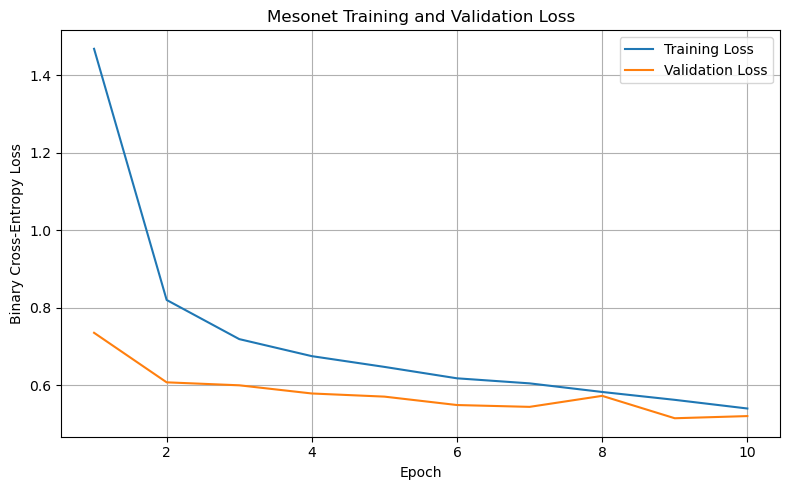

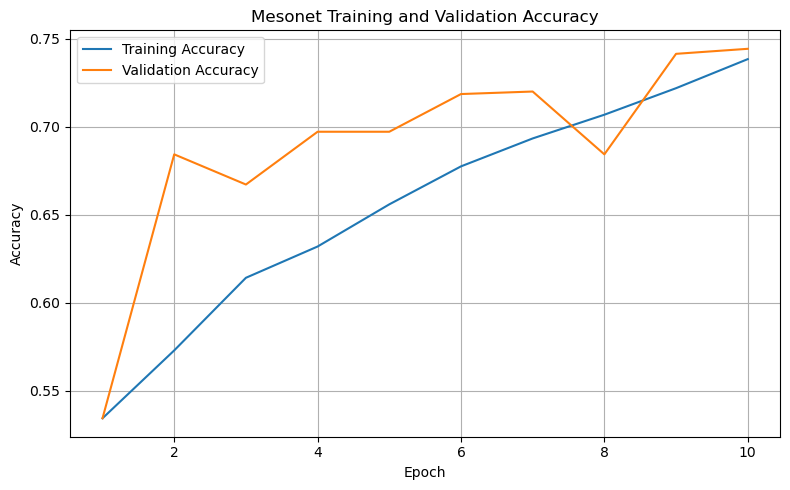

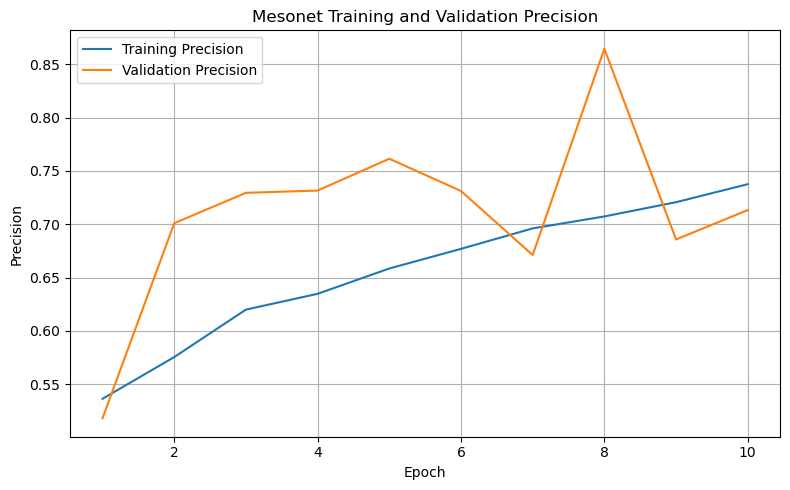

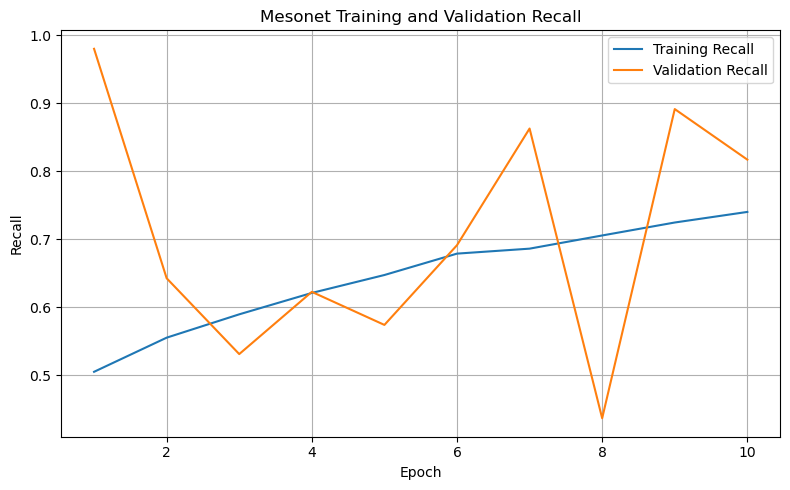

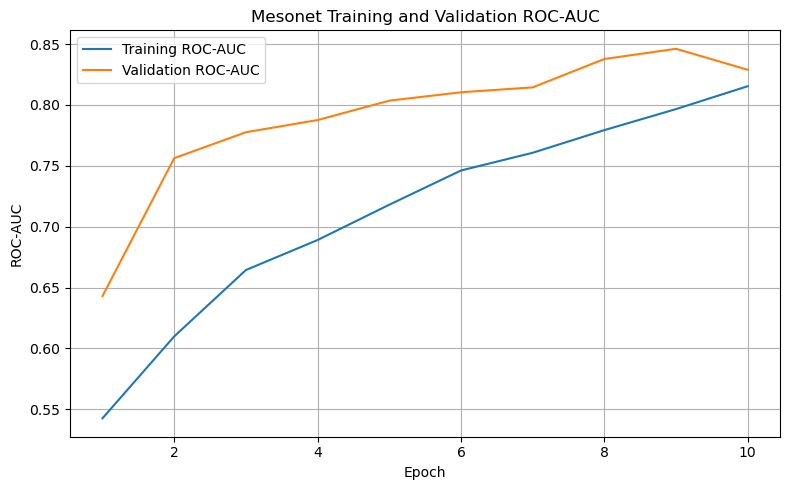

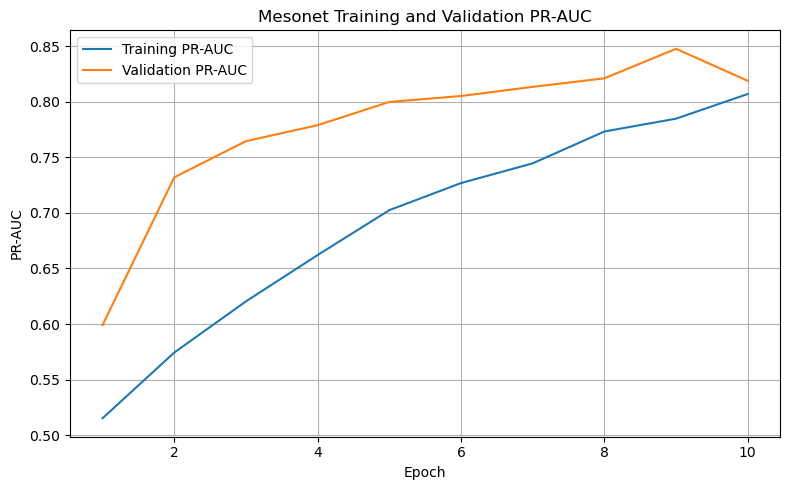

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Mesonet_celeb_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Mesonet_160_dfc.h5")


In [ ]:
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_hog),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_hog[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_hog,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_hog)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_36032\3709879675.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 0.75 seconds, 0.2515 ms/image

Starting resource run 2/5
Run 2: 0.74 seconds, 0.2458 ms/image

Starting resource run 3/5
Run 3: 0.71 seconds, 0.2363 ms/image

Starting resource run 4/5
Run 4: 0.69 seconds, 0.2315 ms/image

Starting resource run 5/5
Run 5: 0.69 seconds, 0.2299 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,0.754536,0.251512,3975.953961,2.851562,4.928125,6016.917969,6199.208496,6278.152344,182.290527,261.234375,...,6957.488281,6957.488281,0.0,0.0,59.000000,95,8.105250,17.209,0.001387,1
1,0.737423,0.245808,4068.221912,2.643750,4.478125,6027.359375,6215.748264,6285.648438,188.388889,258.289062,...,6957.488281,6957.488281,0.0,0.0,62.444444,85,8.454111,14.739,0.001530,2
2,0.708870,0.236290,4232.090674,2.952734,5.375000,6028.089844,6214.940430,6286.718750,186.850586,258.628906,...,6957.488281,6957.488281,0.0,0.0,60.750000,88,8.105500,14.723,0.001548,3
3,0.694436,0.231479,4320.054398,2.358203,3.756250,6029.179688,6212.647461,6287.417969,183.467773,258.238281,...,6957.488281,6957.488281,0.0,0.0,52.875000,84,10.016625,18.445,0.001829,4
4,0.689622,0.229874,4350.210507,2.646875,4.881250,6029.363281,6211.941895,6288.039062,182.578613,258.675781,...,6957.488281,6957.488281,0.0,0.0,55.625000,83,8.912875,18.090,0.001571,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,0.716977,0.028066,0.682128,0.751826
1,latency_ms_per_image,0.238992,0.009355,0.227376,0.250609
2,throughput_images_per_s,4189.306290,162.015726,3988.137197,4390.475384
3,average_cpu_percent,2.690625,0.228702,2.406654,2.974596
4,peak_cpu_percent,4.683750,0.608089,3.928708,5.438792
5,average_ram_mb,6210.897309,6.720512,6202.552691,6219.241927
6,peak_ram_mb,6285.195312,4.035985,6280.183975,6290.206650
7,average_incremental_ram_mb,184.715278,2.741167,181.311670,188.118886
8,peak_incremental_ram_mb,259.013281,1.256983,257.452531,260.574032
9,average_gpu_memory_mb,6957.488281,0.000000,6957.488281,6957.488281



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.239 ± 0.009 (95% CI: 0.227–0.251)
peak_ram_mb: 6285.195 ± 4.036 (95% CI: 6280.184–6290.207)
peak_gpu_memory_mb: 6957.488 ± 0.000 (95% CI: 6957.488–6957.488)
average_gpu_utilization_percent: 58.139 ± 3.877 (95% CI: 53.325–62.953)
average_gpu_power_w: 8.719 ± 0.798 (95% CI: 7.729–9.709)


In [11]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_hog,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_hog,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

188/188 [==============================] - 0s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     3000
Decision threshold:         0.5000
Test loss:                  0.522595

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.742333 (74.23%)
Precision:                  0.712449 (71.24%)
Recall/Sensitivity:         0.812667 (81.27%)
F1-score:                   0.759265 (75.93%)
ROC-AUC:                    0.827000
PR-AUC:                     0.820822
Average Precision:          0.820961
EER:                        0.255667 (25.57%)
EER threshold:              0.546302

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.742333
Specificity:                0.672000
Matthews correlation:       0.489534
False-positive rate @ 0.5:  0.328000
False-negative rate @ 0.5:  0.187333

Confusion matrix
---------------------

#genralization

In [14]:
#wild deepfake on dfc
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on wild deepfake dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 5s 4ms/step - loss: 0.6463 - accuracy: 0.7243 - precision: 0.7464 - recall: 0.9578 - roc_auc: 0.5461 - pr_auc: 0.7698

Test results of DFC on wild deepfake dataset (Mesonet):
loss: 0.6463
accuracy: 0.7243
precision: 0.7464
recall: 0.9578
roc_auc: 0.5461
pr_auc: 0.7698


In [6]:
#celeb on dfc
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on Celeb-DF(V2) dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



373/373 [==============================] - 2s 5ms/step - loss: 1.1046 - accuracy: 0.2000 - precision: 0.8819 - recall: 0.1330 - roc_auc: 0.4468 - pr_auc: 0.8898

Test results of DFC on Celeb-DF(V2) dataset (Mesonet):
loss: 1.1046
accuracy: 0.2000
precision: 0.8819
recall: 0.1330
roc_auc: 0.4468
pr_auc: 0.8898


In [8]:
#FF++ on hog
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of dfc on FF++ dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 1s 4ms/step - loss: 0.9566 - accuracy: 0.4267 - precision: 0.1940 - recall: 0.1193 - roc_auc: 0.3408 - pr_auc: 0.3155

Test results of dfc on FF++ dataset (Mesonet):
loss: 0.9566
accuracy: 0.4267
precision: 0.1940
recall: 0.1193
roc_auc: 0.3408
pr_auc: 0.3155


# FF++

LOAD THE DATASET

In [3]:
import os, cv2, numpy as np

FINAL_ROOT = r'D:\thesis\ff_final'

def load_split(split, cls):
    base = os.path.join(FINAL_ROOT, split, cls)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        d = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(d, f)) for f in sorted(os.listdir(d))]
        if frames:
            nested.append(frames); ids.append(vid_id)
    return nested, ids

# Main splits
ff_real_train_f, ff_real_train_ids = load_split('train', 'real')
ff_fake_train_f, ff_fake_train_ids = load_split('train', 'fake')
ff_real_val_f,   ff_real_val_ids   = load_split('val',   'real')
ff_fake_val_f,   ff_fake_val_ids   = load_split('val',   'fake')
ff_real_test_f,  ff_real_test_ids  = load_split('test',  'real')
ff_fake_test_f,  ff_fake_test_ids  = load_split('test',  'fake')

print("Reloaded main splits. Example shape:", np.shape(ff_real_train_f[0][0]))  # (160,160,3)
print("Real train videos:", len(ff_real_train_f), "| Fake train videos:", len(ff_fake_train_f))
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Combine all frames from the real and fake video groups.

    Labels:
        0 = Real
        1 = Fake
    """

    real_frames = [
        frame
        for video in real_videos
        for frame in video
        if frame is not None
    ]

    fake_frames = [
        frame
        for video in fake_videos
        for frame in video
        if frame is not None
    ]

    if not real_frames:
        raise ValueError("No real frames found.")

    if not fake_frames:
        raise ValueError("No fake frames found.")

    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training data
train_ff, train_ff_labels = combine_split(
    ff_real_train_f,
    ff_fake_train_f
)

# Validation data
val_ff, val_ff_labels = combine_split(
    ff_real_val_f,
    ff_fake_val_f
)

# Testing data
test_ff, test_ff_labels = combine_split(
    ff_real_test_f,
    ff_fake_test_f
)
print("\nTRAIN")
print("Images:", train_ff.shape)
print("Labels:", train_ff_labels.shape)
print("Real:", np.sum(train_ff_labels == 0))
print("Fake:", np.sum(train_ff_labels == 1))

print("\nVALIDATION")
print("Images:", val_ff.shape)
print("Labels:", val_ff_labels.shape)
print("Real:", np.sum(val_ff_labels == 0))
print("Fake:", np.sum(val_ff_labels == 1))

print("\nTEST")
print("Images:", test_ff.shape)
print("Labels:", test_ff_labels.shape)
print("Real:", np.sum(test_ff_labels == 0))
print("Fake:", np.sum(test_ff_labels == 1))

print("\nData types")
print("Train images:", train_ff.dtype)
print("Train labels:", train_ff_labels.dtype)

Reloaded main splits. Example shape: (160, 160, 3)
Real train videos: 517 | Fake train videos: 320

TRAIN
Images: (4595, 160, 160, 3)
Labels: (4595,)
Real: 2948
Fake: 1647

VALIDATION
Images: (948, 160, 160, 3)
Labels: (948,)
Real: 499
Fake: 449

TEST
Images: (2475, 160, 160, 3)
Labels: (2475,)
Real: 1444
Fake: 1031

Data types
Train images: uint8
Train labels: uint8


In [4]:

# Train model
history = model.fit(
    train_ff, train_ff_labels,
    validation_data=(val_ff, val_ff_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
288/288 [==============================] - 6s 11ms/step - loss: 1.1636 - accuracy: 0.5334 - precision: 0.3504 - recall: 0.3534 - roc_auc: 0.4858 - pr_auc: 0.3553 - val_loss: 0.6887 - val_accuracy: 0.5401 - val_precision: 0.5327 - val_recall: 0.2361 - val_roc_auc: 0.5635 - val_pr_auc: 0.5246
Epoch 2/10
288/288 [==============================] - 3s 9ms/step - loss: 0.8088 - accuracy: 0.5878 - precision: 0.3807 - recall: 0.2392 - roc_auc: 0.5101 - pr_auc: 0.3687 - val_loss: 0.7389 - val_accuracy: 0.5253 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5588 - val_pr_auc: 0.5047
Epoch 3/10
288/288 [==============================] - 3s 9ms/step - loss: 0.7675 - accuracy: 0.5885 - precision: 0.3617 - recall: 0.1937 - roc_auc: 0.5077 - pr_auc: 0.3643 - val_loss: 0.7530 - val_accuracy: 0.5264 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5843 - val_pr_auc: 0.5406
Epoch 4/10
288/288 [==============================] - 3s 9ms/step - loss: 0.7

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [6]:
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

155/155 [==============================] - 1s 4ms/step - loss: 0.6812 - accuracy: 0.5838 - precision: 1.0000 - recall: 9.6993e-04 - roc_auc: 0.5832 - pr_auc: 0.4805

Test results:
loss: 0.6812
accuracy: 0.5838
precision: 1.0000
recall: 0.0010
roc_auc: 0.5832
pr_auc: 0.4805


In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 12.7%
RAM Used: 220.1 MB
Time Usage: 2.9 s
GPU Memory Used: 587.5 MB
Power Consumption: 93W


#save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Mesonet_ff_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Mesonet_160_ff.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Mesonet_ff_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


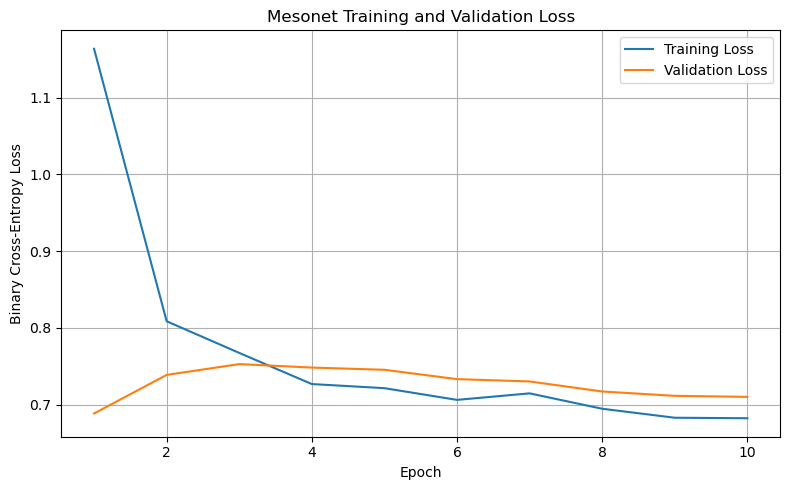

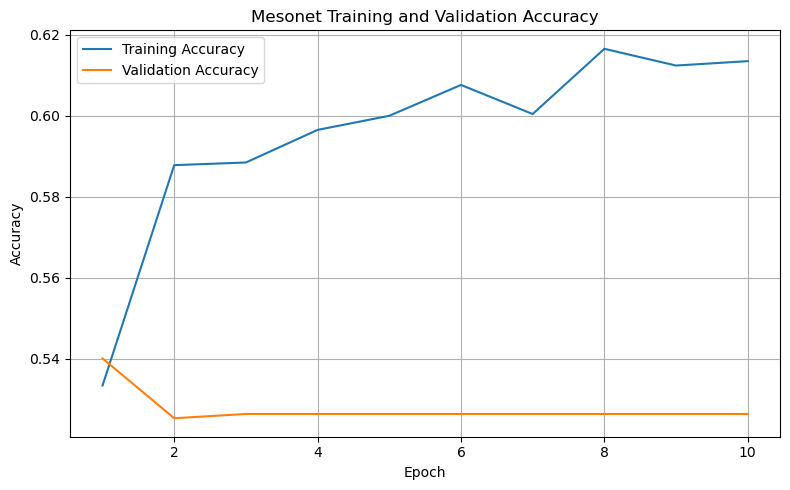

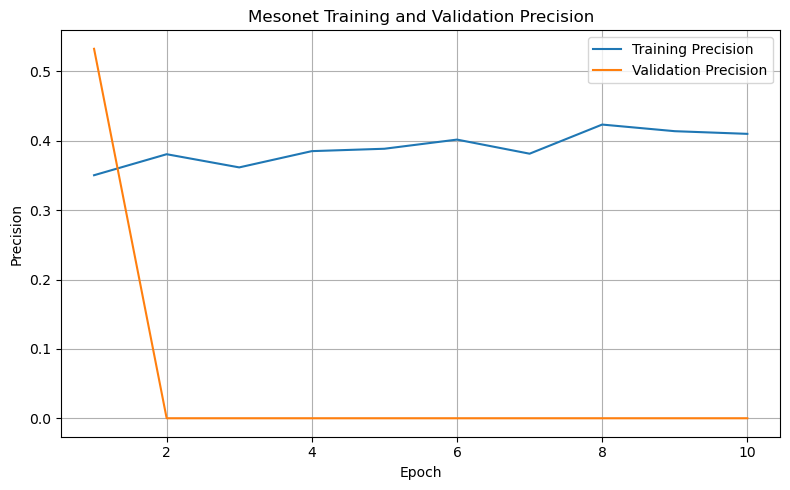

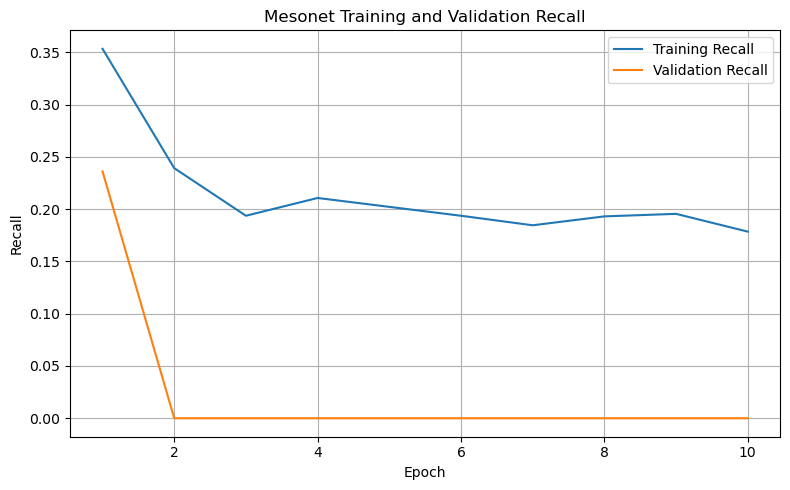

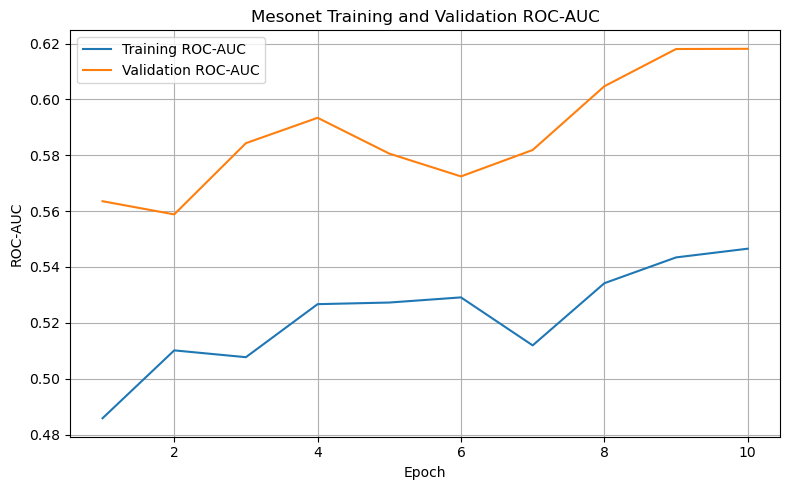

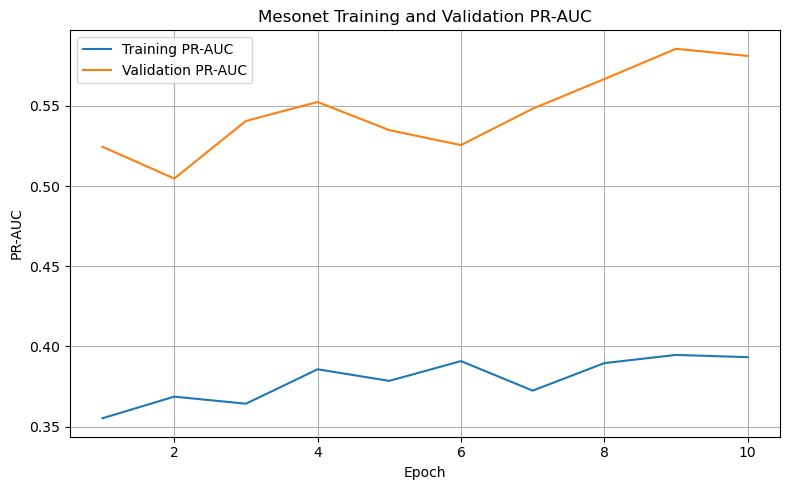

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Mesonet Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Mesonet Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Mesonet Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Mesonet Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Mesonet Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Mesonet Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Mesonet_ff_10epochs.h5")


model = tf.keras.models.load_model(MODEL_PATH,compile=False)

In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_ff),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_ff[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_ff,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_ff)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_39200\115312294.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 0.74 seconds, 0.2999 ms/image

Starting resource run 2/5
Run 2: 0.57 seconds, 0.2320 ms/image

Starting resource run 3/5
Run 3: 0.54 seconds, 0.2169 ms/image

Starting resource run 4/5
Run 4: 0.62 seconds, 0.2508 ms/image

Starting resource run 5/5
Run 5: 0.55 seconds, 0.2228 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,0.742172,0.299868,3334.805588,2.837891,5.825000,4990.488281,5131.154785,5210.839844,140.666504,220.351562,...,6957.488281,6957.488281,0.0,0.0,60.625000,95,6.214125,13.590,0.001093,1
1,0.574112,0.231964,4311.008522,2.731696,4.381250,4996.222656,5146.152344,5218.136719,149.929688,221.914062,...,6957.488281,6957.488281,0.0,0.0,53.714286,83,7.636429,14.210,0.001138,2
2,0.536708,0.216852,4611.450371,2.272396,4.478125,4999.488281,5139.179036,5219.363281,139.690755,219.875000,...,6957.488281,6957.488281,0.0,0.0,52.500000,76,7.108667,11.735,0.000995,3
3,0.620626,0.250758,3987.907055,2.448047,4.031250,5000.492188,5153.467773,5220.226562,152.975586,219.734375,...,6957.488281,6957.488281,0.0,0.0,52.625000,84,8.543125,14.386,0.001312,4
4,0.551448,0.222807,4488.184650,2.861458,4.943750,5000.660156,5138.219401,5221.105469,137.559245,220.445312,...,6957.488281,6957.488281,0.0,0.0,56.000000,81,6.614667,13.701,0.000896,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Mesonet RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,0.605013,0.082985,0.501973,0.708053
1,latency_ms_per_image,0.244450,0.033529,0.202818,0.286082
2,throughput_images_per_s,4146.671237,510.879070,3512.331089,4781.011385
3,average_cpu_percent,2.630298,0.258902,2.308828,2.951767
4,peak_cpu_percent,4.731875,0.692462,3.872070,5.591680
5,average_ram_mb,5141.634668,8.484602,5131.099643,5152.169693
6,peak_ram_mb,5217.934375,4.114762,5212.825224,5223.043526
7,average_incremental_ram_mb,144.164355,6.832869,135.680228,152.648483
8,peak_incremental_ram_mb,220.464063,0.865296,219.389656,221.538469
9,average_gpu_memory_mb,6957.488281,0.000000,6957.488281,6957.488281



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 0.244 ± 0.034 (95% CI: 0.203–0.286)
peak_ram_mb: 5217.934 ± 4.115 (95% CI: 5212.825–5223.044)
peak_gpu_memory_mb: 6957.488 ± 0.000 (95% CI: 6957.488–6957.488)
average_gpu_utilization_percent: 55.093 ± 3.396 (95% CI: 50.876–59.310)
average_gpu_power_w: 7.223 ± 0.910 (95% CI: 6.093–8.354)


In [11]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_ff,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_ff_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Mesonet — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

155/155 [==============================] - 0s 2ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     2475
Decision threshold:         0.5000
Test loss:                  0.681228

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.583838 (58.38%)
Precision:                  1.000000 (100.00%)
Recall/Sensitivity:         0.000970 (0.10%)
F1-score:                   0.001938 (0.19%)
ROC-AUC:                    0.583536
PR-AUC:                     0.481069
Average Precision:          0.481799
EER:                        0.437556 (43.76%)
EER threshold:              0.350241

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.500485
Specificity:                1.000000
Matthews correlation:       0.023793
False-positive rate @ 0.5:  0.000000
False-negative rate @ 0.5:  0.999030

Confusion matrix
----------------------

#gernalization

In [14]:
#wild deepfake on ff
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on wild deepfake dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 5s 4ms/step - loss: 0.8351 - accuracy: 0.2590 - precision: 0.8045 - recall: 0.0159 - roc_auc: 0.4708 - pr_auc: 0.7428

Test results of FF++ on wild deepfake dataset (Mesonet):
loss: 0.8351
accuracy: 0.2590
precision: 0.8045
recall: 0.0159
roc_auc: 0.4708
pr_auc: 0.7428


In [16]:
#celeb on ff
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on Celeb-df(v2) dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 2s 4ms/step - loss: 0.9642 - accuracy: 0.0956 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 0.5433 - pr_auc: 0.9124

Test results of FF++ on Celeb-df(v2) dataset (Mesonet):
loss: 0.9642
accuracy: 0.0956
precision: 0.0000
recall: 0.0000
roc_auc: 0.5433
pr_auc: 0.9124


In [18]:
#DFC on ff
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on DFC dataset (Mesonet):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


188/188 [==============================] - 1s 6ms/step - loss: 0.6990 - accuracy: 0.5297 - precision: 0.5420 - recall: 0.3827 - roc_auc: 0.5384 - pr_auc: 0.5296

Test results of FF++ on DFC dataset (Mesonet):
loss: 0.6990
accuracy: 0.5297
precision: 0.5420
recall: 0.3827
roc_auc: 0.5384
pr_auc: 0.5296
